In [1]:
import os
from typing import List
from typing import Sequence
from typing import Tuple

from torchvision.datasets import Omniglot
from torchvision import transforms
from torch.utils.data import DataLoader

import torch 
import numpy as np


In [2]:
download_dir = '../dat/omniglot'

In [6]:
train_data = Omniglot(download_dir,background=True,download=True,transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 9464212/9464212 [00:00<00:00, 97950427.99it/s]


Extracting ./data/omniglot/omniglot-py/images_background.zip to ./data/omniglot/omniglot-py


In [77]:
alphabet_name = train_data._characters[300].split('/')[0]
train_data._alphabets.index(alphabet_name)

10

In [89]:
import os
from torchvision.datasets import Omniglot
from torchvision.transforms import ToTensor
from PIL import Image

class OmniglotWithAlphabet(Omniglot):
    def __init__(self, root, background=True, transform=None, target_transform=None, download=False):
        super().__init__(root, background=background, transform=transform, target_transform=target_transform, download=download)

        self.num_alphabets = len(self._alphabets)

    def __getitem__(self, index: int):
        """
        Args:
            index (int): Index

        Returns:
            tuple: (image, target) where target is index of the target character class.
        """
        image_name, character_class = self._flat_character_images[index]
        image_path = os.path.join(self.target_folder, self._characters[character_class], image_name)
        alphabet_name = self._characters[character_class].split('/')[0]
        alphabet_label = self._alphabets.index(alphabet_name)
        image = Image.open(image_path, mode="r").convert("L")

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            character_class = self.target_transform(character_class)

        return image, character_class, alphabet_label
    

In [90]:
# Concatenate all images in the dataset
all_images = torch.cat([train_data[i][0].unsqueeze(0) for i in range(len(train_data))], dim=0)

# Calculate mean and standard deviation
mean = all_images.mean(dim=[0,2,3])
std = all_images.std(dim=[0,2,3])



In [91]:
print(f"Mean: {mean}, Standard Deviation: {std}")

Mean: tensor([0.9221]), Standard Deviation: tensor([0.2681])


In [92]:
mean.shape

torch.Size([1])

In [93]:
mean=[0.9221]
std=[0.2681]

# OMNIGLOT
dat={}
dat['train']=OmniglotWithAlphabet(download_dir,background=True,download=True,transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean,std)]))

Files already downloaded and verified


In [99]:
# Concatenate all images in the dataset
all_labels = [train_data[i][1] for i in range(len(train_data))]

In [3]:
import importlib

In [12]:
from dataloaders import omniglot
importlib.reload(omniglot)

<module 'dataloaders.omniglot' from '/pub/hofmann-scratch/glanzillo/gvcl_fork/src/dataloaders/omniglot.py'>

In [13]:
data, taskcla, size = omniglot.get(path='../dat/', resize=True)

Files already downloaded and verified
Files already downloaded and verified
Generating dataset files... (this may take a while)


100%|██████████| 6492/6492 [00:10<00:00, 619.22it/s]
/pub/hofmann-scratch/glanzillo/gvcl_fork/src/dataloaders/omniglot.py:124: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  data[t][s]['y']=torch.LongTensor(np.array(data[t][s]['y'],dtype=int)).view(-1)
/pub/hofmann-scratch/glanzillo/gvcl_fork/src/dataloaders/omniglot.py:125: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first

In [17]:
data[0]['test']['y'].unique()

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33])

In [63]:
data[7]['train']['x'].shape

torch.Size([462, 1, 28, 28])

In [89]:
data[2]['train']['y'].min()

tensor(63)

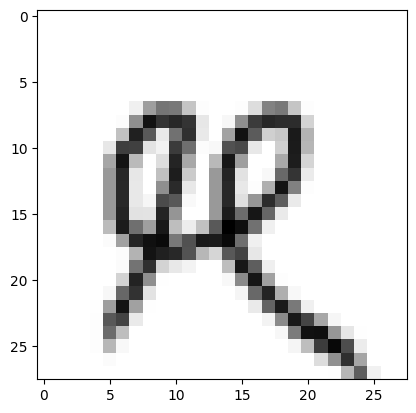

In [50]:

import matplotlib.pyplot as plt

plt.imshow(data[7]['train']['x'][200][0], cmap='gray')
plt.show()


In [57]:
from torchvision import transforms


In [77]:
training_alphabets= omniglot.OmniglotWithAlphabet(download_dir,background=True,download=True,transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize(omniglot.OmniglotWithAlphabet.mean,omniglot.OmniglotWithAlphabet.std)]), resize=(105,105))

Files already downloaded and verified


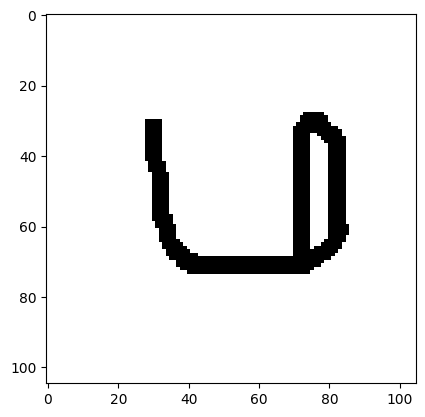

In [78]:

plt.imshow(training_alphabets[0][0][0], cmap='gray')
plt.show()

## Testing the loss

In [1]:
import sys,os,argparse,time
import numpy as np
import torch
from best_hyperparams import get_best_params, sweep_params

import utils
import setup

In [2]:
from approaches import gvcl as approach
from dataloaders import cifar as dataloader
from networks.gvcl_models import ZenkeNetNoFiLM as network


In [3]:

tstart=time.time()
root_path = '../' #change to match running directory


np.random.seed(11)
torch.manual_seed(11)
if torch.cuda.is_available(): torch.cuda.manual_seed(11)
else: print('[CUDA unavailable]'); sys.exit()


# Load
print('Load data...')
default_path = root_path+"dat/" #pick this otherwise
data,taskcla,inputsize=dataloader.get(seed=11, path=default_path)
print('Input size =',inputsize,'\nTask info =',taskcla)

Load data...
Task order = [0, 1, 2, 3, 4, 5]
Input size = [3, 32, 32] 
Task info = [(0, 10), (1, 10), (2, 10), (3, 10), (4, 10), (5, 10)]


In [4]:

# Inits
from argparse import Namespace


print('Inits...')
net=network.Net(inputsize,taskcla).cuda()
utils.print_model_report(net)

Inits...
----------------------------------------------------------------------------------------------------
Net(
  (conv_layers): ModuleList(
    (0): MFConvLayer(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MFConvLayer(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): MFConvLayer(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MFConvLayer(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_layers): ModuleList(
    (0): MFLinearLayer()
  )
  (heads): ModuleList(
    (0-5): 6 x MFLinearLayer()
  )
)
Dimensions = torch.Size([32, 3, 3, 3]) torch.Size([32]) torch.Size([32, 3, 3, 3]) torch.Size([32]) torch.Size([32, 32, 3, 3]) torch.Size([32]) torch.Size([32, 32, 3, 3]) torch.Size([32]) torch.Size([64, 32, 3, 3]) torch.Size([64]) torch.Size([64, 32, 3, 3]) torch.Size([64]) torch.Size([64, 64, 3, 3]) torch.Size([64]) torch.Size([64, 64, 3, 3]) torch.Size([64]) torch.Size([512, 4096]) torch.Size([512]) torch.Size([

4388024

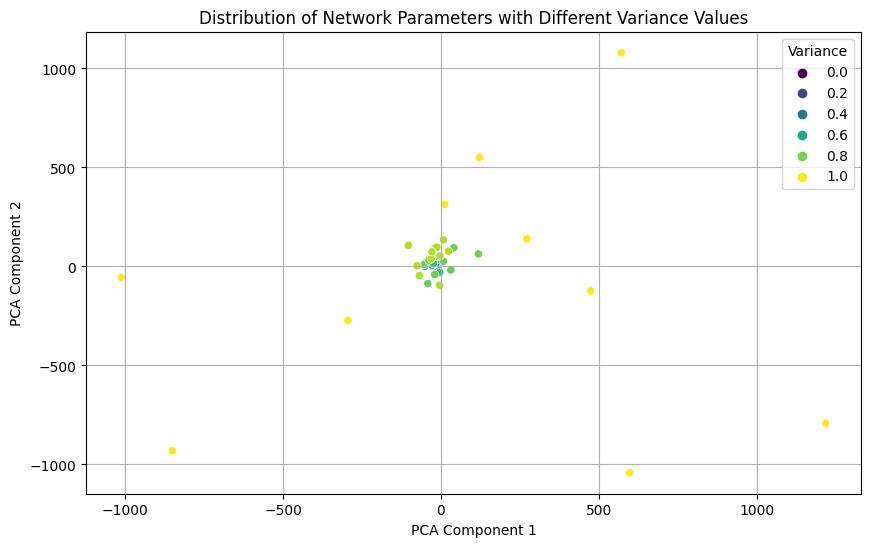

In [ ]:
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Initialize a list to store the sampled parameters
sampled_params = []
# Generate a list of variance values in linspace from 0 to 1
var_values = np.linspace(0, 1, num=10)
# Sample the network parameters multiple times 
num_samples = 10

# Loop over each variance value
for var in var_values:
    # Loop over each sample
    for sample_idx in range(num_samples):
        # Sample the network parameters
        net.sample_parameters(mean=mean, variance=var)
        # Extract the parameters and flatten them
        params = torch.cat([p.flatten() for p in net.parameters()]).cpu().detach().numpy()
        # Store the parameters along with the variance and sample index
        sampled_params.append({'params': params, 'var': var, 'sample_idx': sample_idx})

# Convert the list to a DataFrame
params_df = pd.DataFrame(sampled_params)

# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
params_2d = pca.fit_transform(np.stack(params_df['params'].values))

# Add the PCA results to the DataFrame
params_df['pca1'] = params_2d[:, 0]
params_df['pca2'] = params_2d[:, 1]


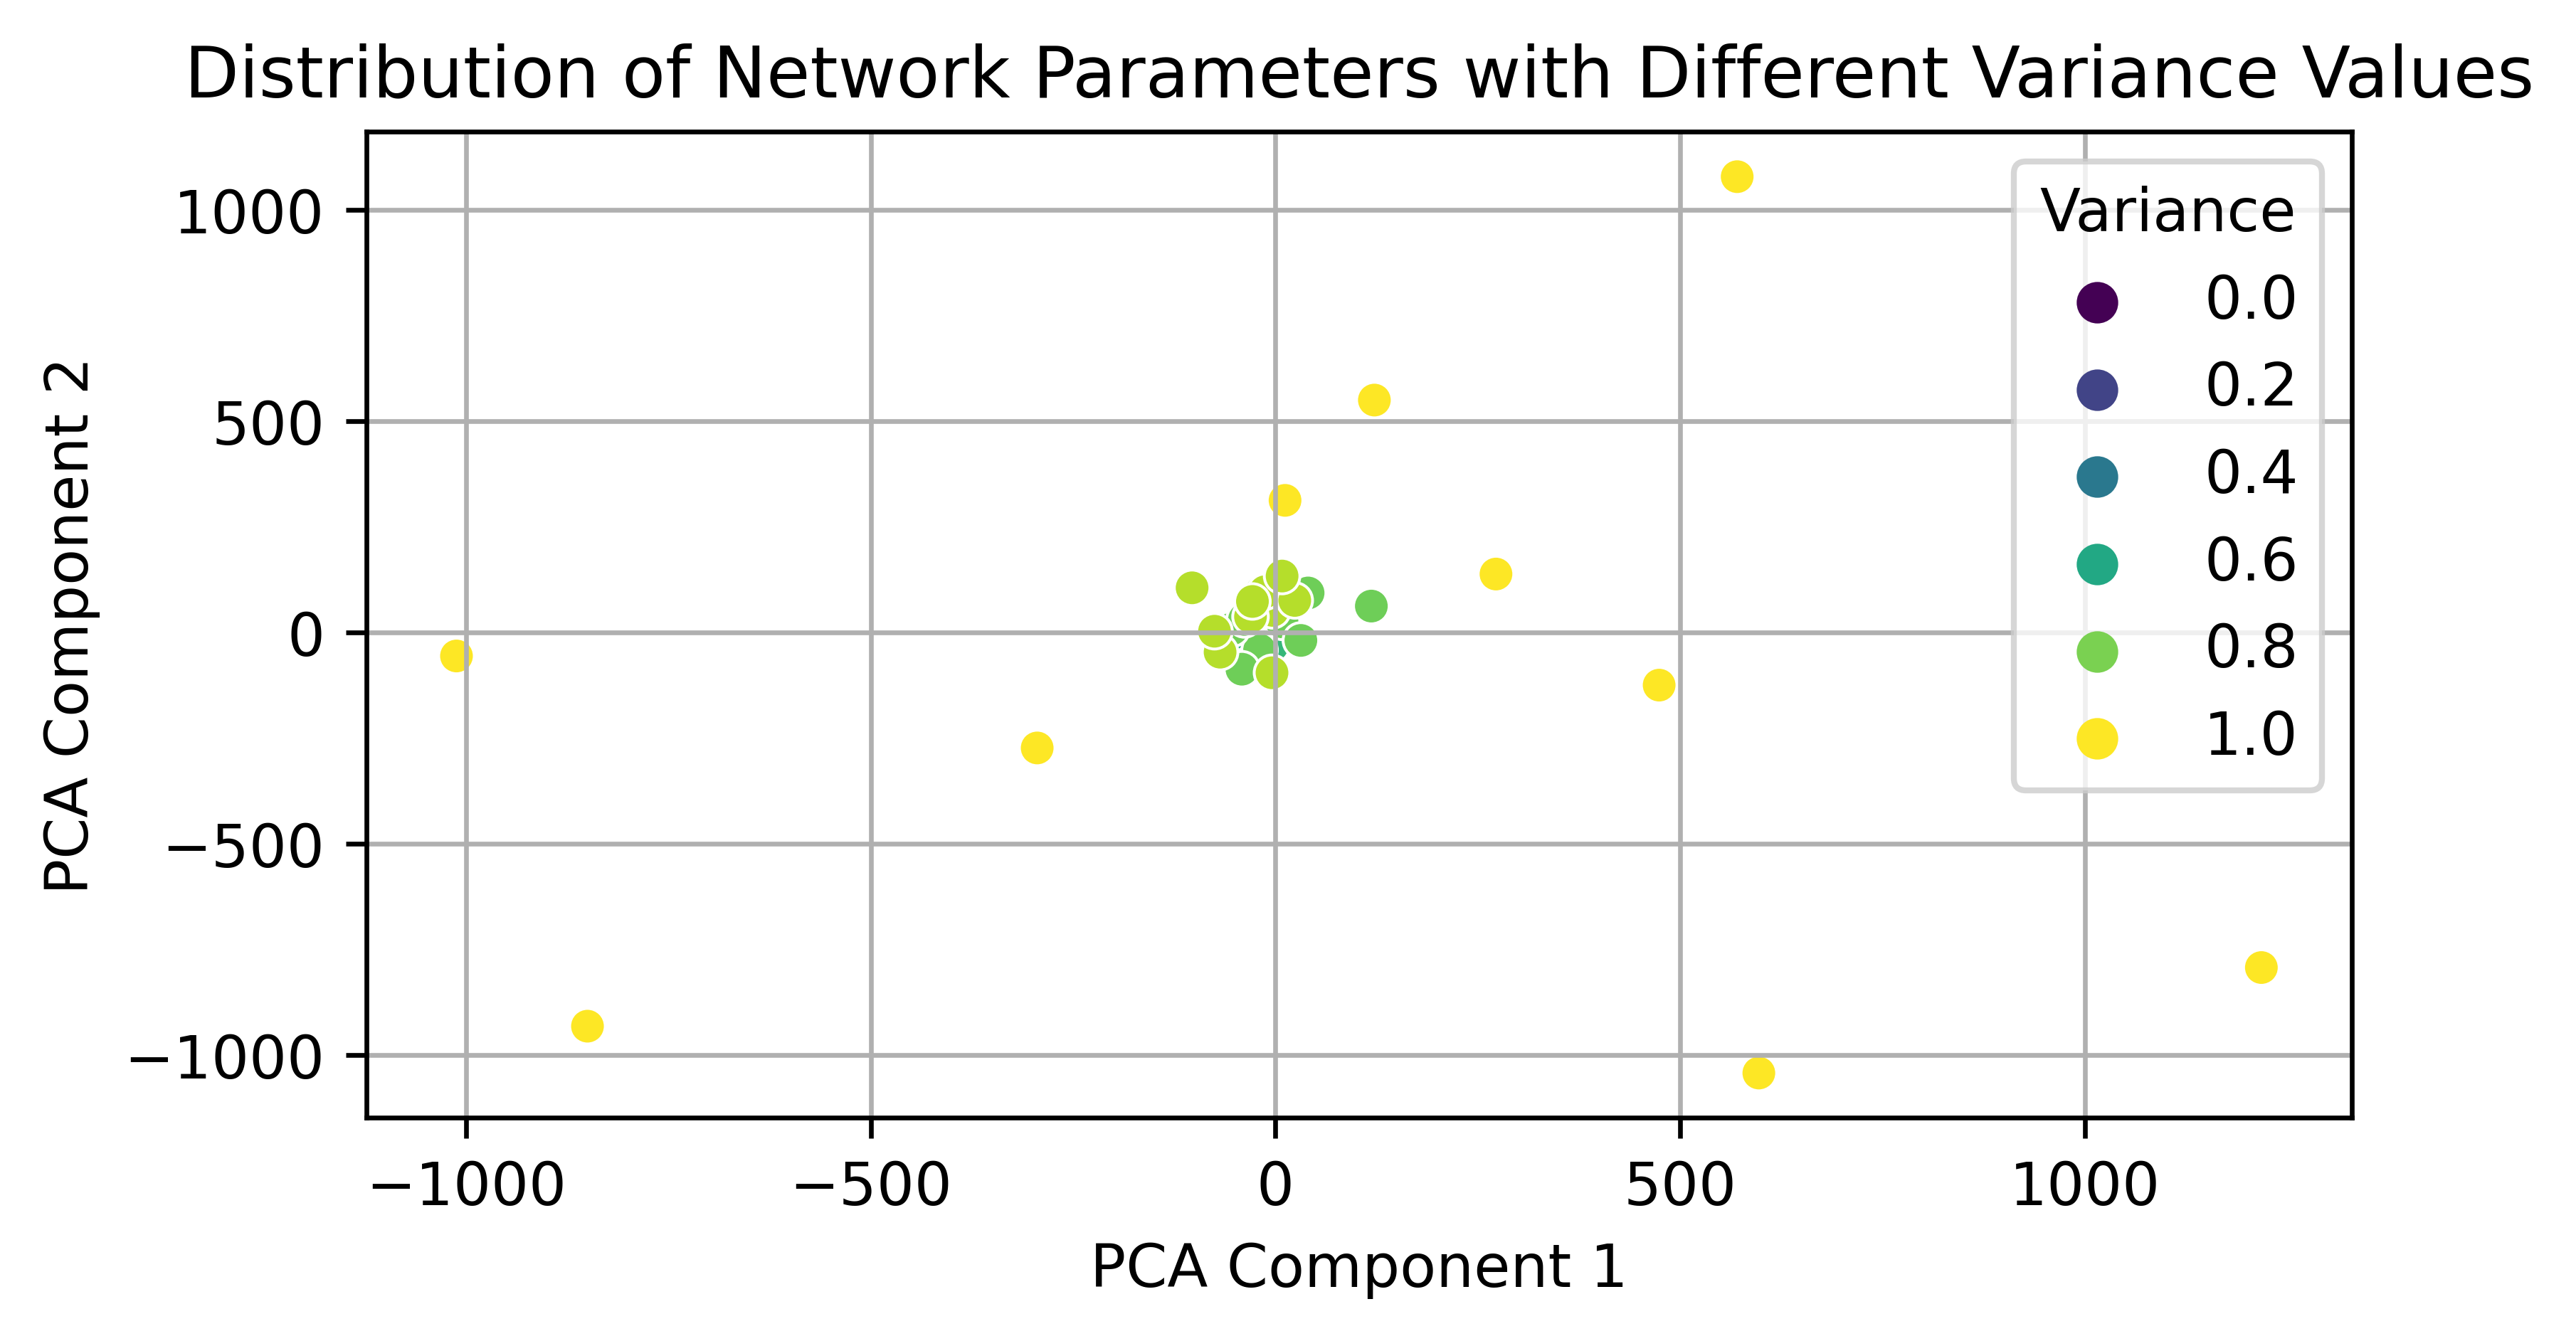

In [27]:

# Create a 2D visualization of the distribution of the network parameters
plt.figure(figsize=(6, 3), dpi=600)
sns.scatterplot(data=params_df, x='pca1', y='pca2', hue='var', palette='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Distribution of Network Parameters with Different Variance Values')
plt.legend(title='Variance')
plt.grid(True)
plt.show()

In [ ]:
# Generate a list of variance values in linspace from 0 to 1
var_values = np.linspace(0, 1, num=10)
# Generate a list of q values in logspace from very close to 1 to 10
q_values = np.linspace(1 + 1e-6, 3-1e-6, num=100)
# Initialize a dataframe to store the results
results_df = pd.DataFrame(columns=['q', 'reg', 'reg_true'])
# Sample the network parameters multiple times for each q value
num_samples = 10
lamb = 1.0
v = 0.1
mean=0

# Loop over each variance value
for var in var_values:
   # Loop over each q value
   for sample_idx in range(num_samples):
      net.sample_parameters(mean=mean, variance=var)
      for q in q_values:
         reg = net.get_reg(lamb=lamb, reg_type="re_g", q=q, v=v)
         reg_true = net.get_reg(lamb=lamb, reg_type="kl_g", q=q, v=v)
         results = pd.DataFrame({'q': q, 'reg': reg.item(), 'reg_true': reg_true.item(), 'sample_idx': sample_idx, 'var': var}, index=[0])
         results_df = pd.concat([results, results_df])

In [49]:
results_df

,q,reg,reg_true,sample_idx,var
0,2.999999,NaN,2907831.0,9.0,1.0
0,2.979797,NaN,2907831.0,9.0,1.0
0,2.959595,NaN,2907831.0,9.0,1.0
0,2.939393,NaN,2907831.0,9.0,1.0
0,2.919191,NaN,2907831.0,9.0,1.0
...,...,...,...,...,...
0,1.080809,0.000000,0.0,0.0,0.0
0,1.060607,0.539432,0.0,0.0,0.0
0,1.040405,0.000000,0.0,0.0,0.0
0,1.020203,0.000000,0.0,0.0,0.0


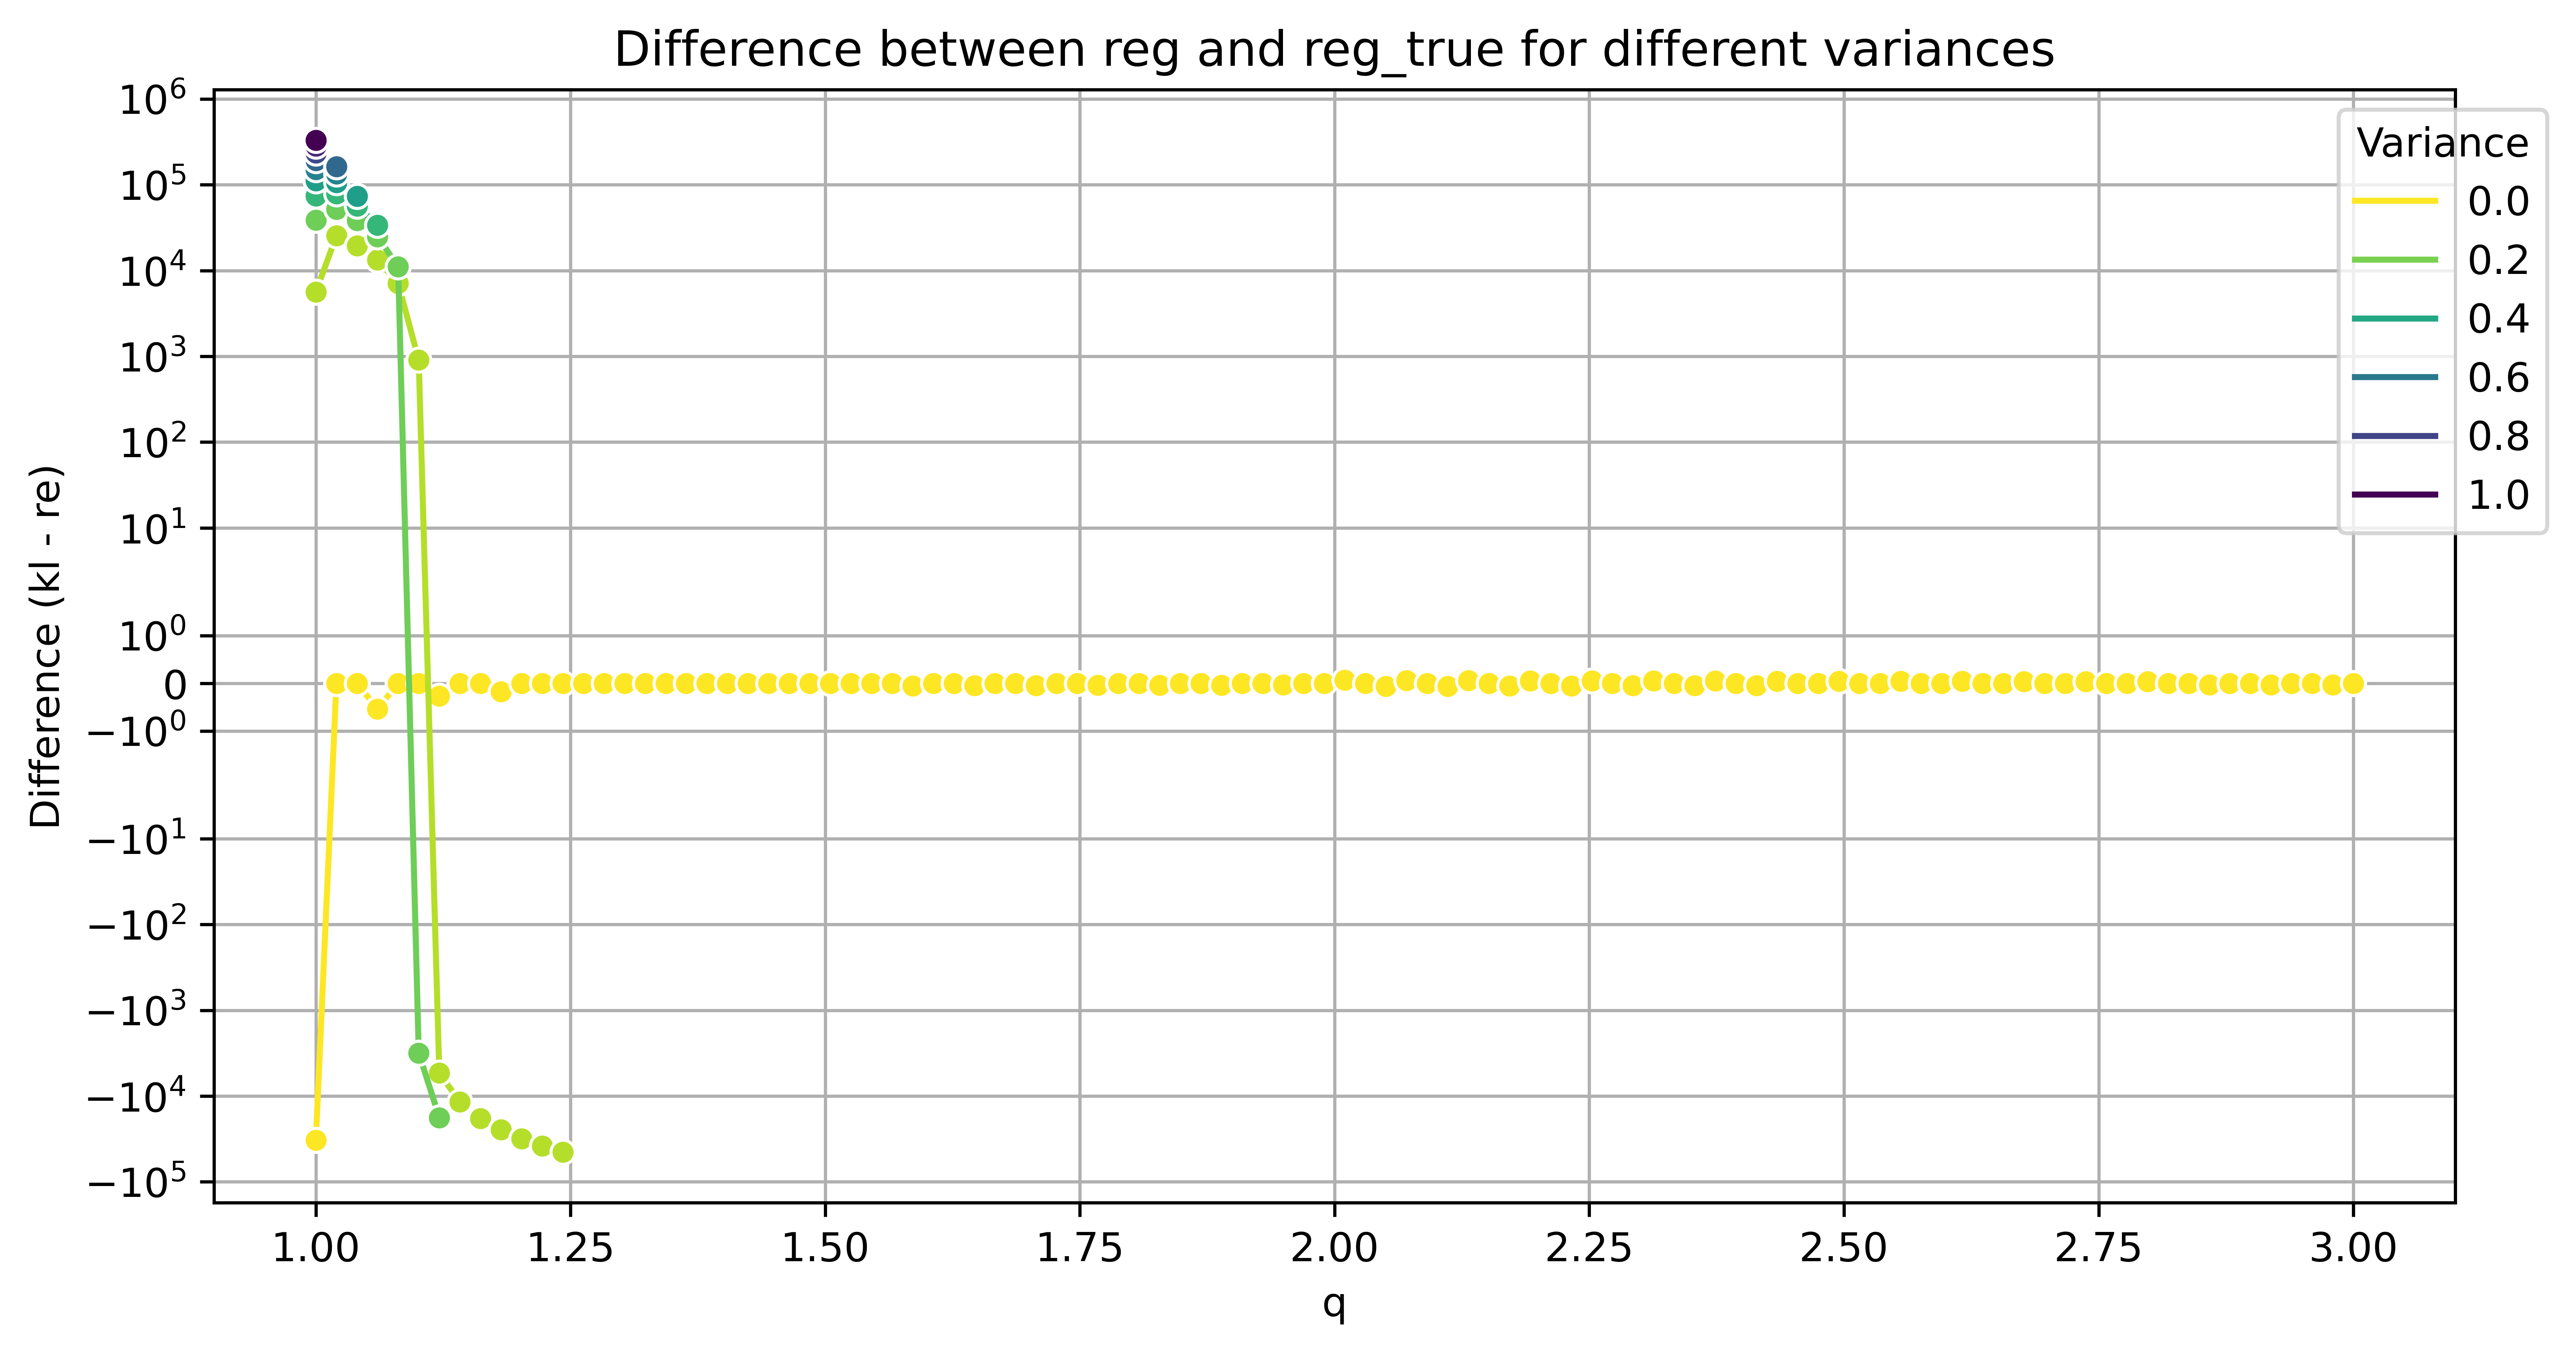

In [56]:
import seaborn as sns
# Calculate the difference between reg and reg_true
results_df['difference'] = results_df['reg_true'] - results_df['reg']
# Plot the difference for different variances
plt.figure(figsize=(10, 5), dpi=800)
# Replace NaNs with 0 for plotting
results_df.dropna(subset=['difference'], inplace=True)
plt.yscale('symlog')
sns.lineplot(data=results_df, x='q', y='difference', hue='var', marker='o', palette="viridis_r")
plt.xlabel('q')
plt.ylabel('Difference (kl - re)')
plt.title('Difference between reg and reg_true for different variances')
plt.grid(True)
plt.legend(title='Variance', bbox_to_anchor=(1.05, 1))
plt.show()

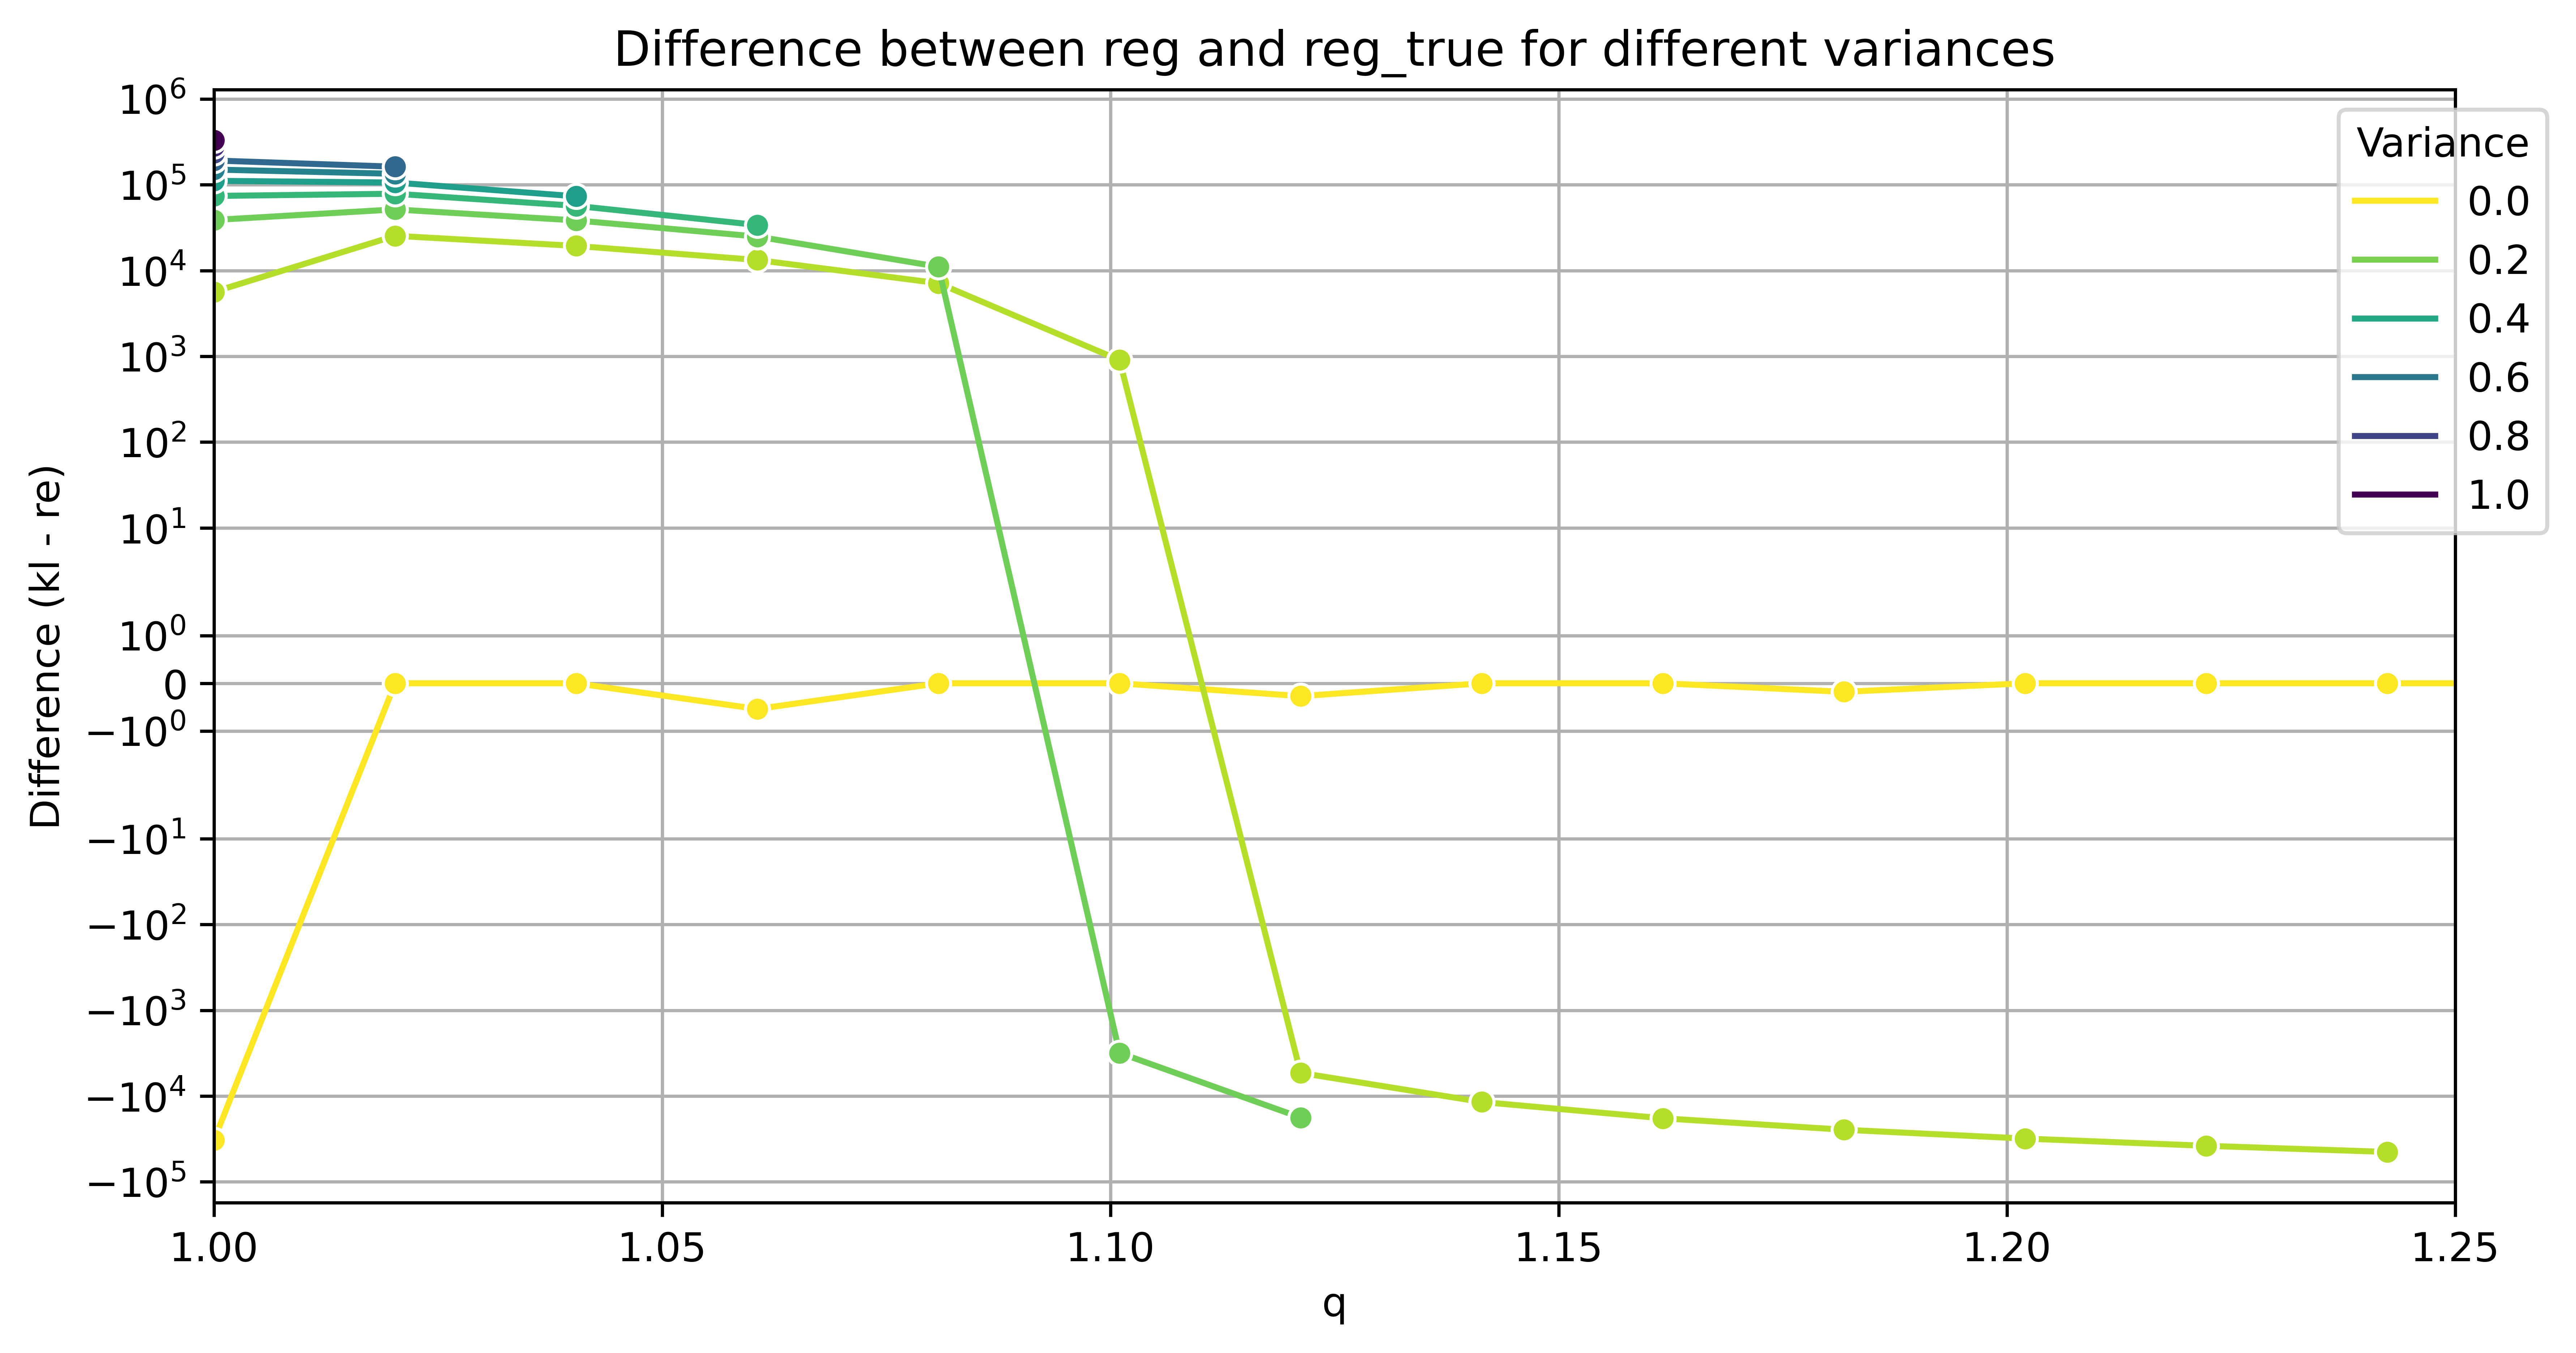

In [55]:
import seaborn as sns
# Calculate the difference between reg and reg_true
results_df['difference'] = results_df['reg_true'] - results_df['reg']
# Plot the difference for different variances
plt.figure(figsize=(10, 5), dpi=800)
# Replace NaNs with 0 for plotting
results_df.dropna(subset=['difference'], inplace=True)
plt.yscale('symlog')
plt.xlim(1, 1.25)
sns.lineplot(data=results_df, x='q', y='difference', hue='var', marker='o', palette="viridis_r")
plt.xlabel('q')
plt.ylabel('Difference (kl - re)')
plt.title('Difference between reg and reg_true for different variances')
plt.grid(True)
plt.legend(title='Variance', bbox_to_anchor=(1.05, 1))
plt.show()